In [ ]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator
# from src.graphconstruction import StaticGraphOrchestrator, DynamicGraphOrchestrator

from src.newgraphconstruction.orchestrators import StaticGraphOrchestrator, DynamicGraphOrchestrator

disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = 'influenza',
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = False,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'cases',
    lag_column          = 'incidence',  
    verbose             = 0
    )    
data_orchestrator = DataOrchestrator(config).build()

In [ ]:
dynamic_graphconstruction = DynamicGraphOrchestrator(data_orchestrator)
dynamic_graphconstruction.generate_graphstructure(method = 'gravity_model', time_window=['2001-01-01','2025-01-01'], frequency = 'yearly', graphname='dynamic_gravity')

    ✓ Graph registered  : dynamic_gravity successfully registered


In [ ]:
static_graphconstruction = StaticGraphOrchestrator(data_orchestrator)

# identity graph
static_graphconstruction.generate_graphstructure(method = 'identity', graphname='identity_graph')

# mesh graph
static_graphconstruction.generate_graphstructure(method = 'mesh', graphname='mesh_graph')

# Neighbors
#   boolean-self
static_graphconstruction.generate_graphstructure(method='geographic_neighbors', self_connection='mean', graphname = 'geographical_neighbors1')
#   boolean-nonself
static_graphconstruction.generate_graphstructure(method='geographic_neighbors', self_connection='0', graphname = 'geographical_neighbors2')
#   numerical-self
static_graphconstruction.generate_graphstructure(method='geographic_neighbors', self_connection = 'mean', scaling_method='rowwise', graphname = 'geographical_neighbors3')
#   numerical-nonself
static_graphconstruction.generate_graphstructure(method='geographic_neighbors', self_connection='0', scaling_method='rowwise', graphname = 'geographical_neighbors4')


    ✓ Graph registered  : identity_graph successfully registered
    ✓ Graph registered  : mesh_graph successfully registered
    ✓ Graph registered  : geographical_neighbors1 successfully registered
    ✓ Graph registered  : geographical_neighbors2 successfully registered
    ✓ Graph registered  : geographical_neighbors3 successfully registered
    ✓ Graph registered  : geographical_neighbors4 successfully registered


In [ ]:
static_graphconstruction.generate_graphstructure(
    method              = 'commuter', 
    self_connection     = '0',
    commuting_threshold = 500,
    scaling_method      = 'rowwise',
    graphname           = 'static_commuter24_1'
)

ValueError: Unknown graph generation method: 'commuter'. Available methods: geographic_neighbors, identity, mesh, gravity_model

AttributeError: 'DynamicGraphStructure' object has no attribute 'edge_index'

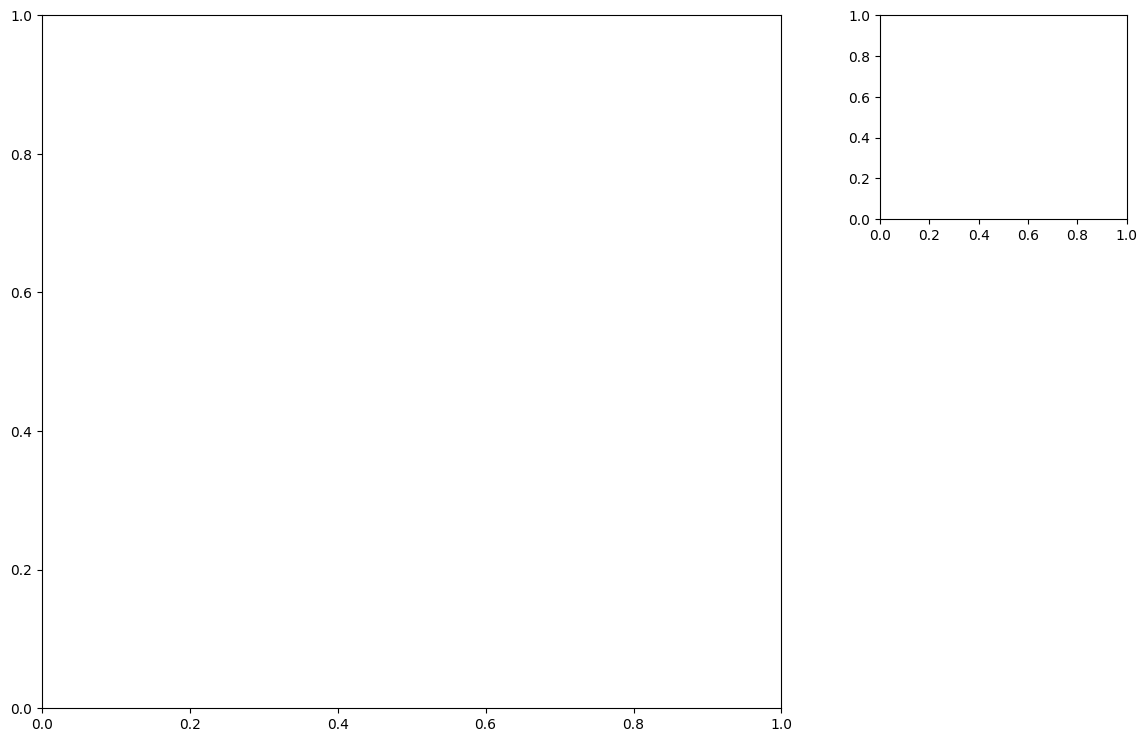

In [ ]:
dynamic_graphconstruction.preview_graphstructure('dynamic_gravity')